### Project overview

This notebook builds a collocated SAR-GPM IMERG dataset for rainfall characterization over SAR observations.
The goal is to pair each sampled SAR pixel with the nearest IMERG rain-rate value so the influence of rainfall on VV and VH backscatter can be analyzed consistently.

In [1]:
#Importing all the libraries that the whole script needs

import xarray as xr
import h5py
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import Point
from scipy.spatial import cKDTree
from sklearn.linear_model import LinearRegression
from matplotlib.widgets import Slider
from matplotlib.colors import LogNorm
from skimage import exposure

### Configure input files

Define the SAR NetCDF input, the IMERG HDF5 precipitation file, the output parquet name, and the sampling stride used later in the workflow. The stride controls how densely the SAR scene is sampled before collocation, which is a practical tradeoff between spatial detail and runtime when working with large SAR rasters.

In [2]:
# ==========================================================
# USER SETTINGS
# ==========================================================

SAR_NC = r"SAR_2.nc"

IMERG_FILE = r"IMERG_2.HDF5"

OUTPUT_PARQUET = "collocated_2.parquet"

STRIDE = 40

### Load the SAR scene

Open the Sentinel-1 SAR scene, extract the VV and VH backscatter channels together with the incidence angle and geographic coordinates, then downsample the grid to a manageable set of representative pixels. This step prepares the radar observation for pixel-wise pairing with IMERG rainfall so the later analysis can focus on how rain changes SAR backscatter signatures.

In [ ]:
# ==========================================================
# STAGE 1 : LOAD SAR NETCDF
# ==========================================================

print("\n[1/7] Loading SAR NetCDF...")

ds = xr.open_dataset(
    SAR_NC,
    engine="netcdf4"
)

vv = ds["Sigma0_VV_db"].values
vh = ds["Sigma0_VH_db"].values

incidence_angle = ds["incidenceAngleFromEllipsoid"].values

sar_lat = ds["lat"].values
sar_lon = ds["lon"].values

rows, cols = np.indices(vv.shape)

rows = rows[::STRIDE, ::STRIDE]
cols = cols[::STRIDE, ::STRIDE]

vv = vv[::STRIDE, ::STRIDE]
vh = vh[::STRIDE, ::STRIDE]

incidence_angle = incidence_angle[::STRIDE, ::STRIDE]

lat = sar_lat[rows]
lon = sar_lon[cols]

print("SAR loaded.")
print("Sampled pixels:", vv.size)



[1/7] Loading SAR NetCDF...


### Flatten the sampled SAR arrays

Convert the downsampled latitude, longitude, backscatter, and incidence-angle grids into 1D vectors. Collocation is easier in this form because each row now represents one SAR pixel with a precise location that can be matched to the nearest IMERG grid cell.

In [ ]:
# ==========================================================
# STAGE 2 : FLATTEN ARRAYS
# ==========================================================

print("\n[2/7] Flattening arrays...")

lat = lat.flatten()
lon = lon.flatten()

vv = vv.flatten()
vh = vh.flatten()

incidence_angle = incidence_angle.flatten()

print("Total sampled points:", len(vv))


[2/7] Flattening arrays...
Total sampled points: 362376


### Load IMERG rainfall

Read the IMERG precipitation field from the HDF5 product and select whichever rainfall dataset is present, since different IMERG files may expose either the raw or calibrated precipitation variable. IMERG is a multi-satellite precipitation product from the GPM mission, updated every half hour, and it is especially valuable for oceanic and remote regions where ground rainfall measurements are sparse. The rainfall array is also normalized to a consistent orientation so it can be matched correctly with the SAR coordinate grid.

In [ ]:
# ==========================================================
# STAGE 3 : LOAD IMERG
# ==========================================================

print("\n[3/7] Loading IMERG...")

with h5py.File(IMERG_FILE, "r") as f:

    if "Grid/precipitation" in f:
        rain = f["Grid/precipitation"][:]
        print("\nUsing Grid/precipitation")

    elif "Grid/precipitationCal" in f:
        rain = f["Grid/precipitationCal"][:]
        print("\nUsing Grid/precipitationCal")

    else:
        raise Exception(
            "Could not find precipitation dataset."
        )

    imerg_lat = f["Grid/lat"][:]
    imerg_lon = f["Grid/lon"][:]

rain = np.squeeze(rain)

# IMERG sometimes comes as [lon,lat]
if rain.shape[0] == len(imerg_lon):
    rain = rain.T

print("Rain shape:", rain.shape)
print("IMERG loaded.")


[3/7] Loading IMERG...

Using Grid/precipitation
Rain shape: (1800, 3600)
IMERG loaded.


### Build the IMERG lookup tree

Build a KDTree from the IMERG latitude-longitude grid so the nearest rainfall pixel can be found efficiently for every sampled SAR observation. This is the spatial indexing step that makes the SAR-to-IMERG collocation fast enough for a dense scene, while still preserving a physically meaningful nearest-neighbor match in geographic space.

In [ ]:
# ==========================================================
# STAGE 4 : BUILD KD TREE
# ==========================================================

print("\n[4/7] Building KDTree...")

lon_grid, lat_grid = np.meshgrid(
    imerg_lon,
    imerg_lat
)

imerg_points = np.column_stack(
    (
        lat_grid.ravel(),
        lon_grid.ravel()
    )
)

tree = cKDTree(imerg_points)

print("IMERG cells:", len(imerg_points))


[4/7] Building KDTree...
IMERG cells: 6480000


### Collocate SAR to IMERG

Query the IMERG KDTree for each SAR pixel and attach the rainfall value from the closest precipitation grid cell. This creates the core collocated sample table used by the project objective: studying how GPM IMERG rain rates relate to SAR backscatter under matched location and acquisition conditions.

In [ ]:
# ==========================================================
# STAGE 5 : COLLOCATION
# ==========================================================

print("\n[5/7] Collocating SAR -> IMERG...")

sar_points = np.column_stack(
    (
        lat,
        lon
    )
)

dist, idx = tree.query(
    sar_points,
    k=1
)

rain_flat = rain.ravel()

rain_values = rain_flat[idx]

print("Collocation complete.")


[5/7] Collocating SAR -> IMERG...
Collocation complete.


### Filter invalid samples

Remove rows with non-finite SAR values, missing incidence angles, or invalid rainfall values before saving the final table. Cleaning the collocated samples prevents NaNs and negative rain rates from biasing the later summaries, regression fits, and correlation plots.

### Data quality note

SAR scenes often contain NaN pixels where the radar measurement is invalid or uninformative, such as in shadowed areas, processing gaps, or other masked regions. Those values are not the same as zero backscatter, so they must be excluded before characterizing rainfall effects in the collocated SAR-GPM dataset.

In [ ]:
# ==========================================================
# STAGE 6 : FILTER INVALID DATA
# ==========================================================

print("\n[6/7] Filtering invalid samples...")

mask = (
    np.isfinite(vv)
    &
    np.isfinite(vh)
    &
    np.isfinite(incidence_angle)
    &
    np.isfinite(rain_values)
    &
    (rain_values >= 0)
)

lat = lat[mask]
lon = lon[mask]

vv = vv[mask]
vh = vh[mask]

incidence_angle = incidence_angle[mask]

rain_values = rain_values[mask]

print("Remaining samples:", len(vv))


[6/7] Filtering invalid samples...
Remaining samples: 238408


### Save the collocated dataset

Write the cleaned SAR and IMERG rows to parquet so the collocated dataset can be reused without repeating the expensive read, downsample, and nearest-neighbor matching steps. Saving the file at this stage also preserves the main analysis input in a compact tabular form for the later plots and statistical checks.

In [ ]:
# ==========================================================
# STAGE 7 : SAVE PARQUET
# ==========================================================

print("\n[7/7] Saving parquet...")

df = pd.DataFrame(
    {
        "lat": lat.astype(np.float32),
        "lon": lon.astype(np.float32),

        "VV_dB": vv.astype(np.float32),
        "VH_dB": vh.astype(np.float32),

        "incidence_angle": incidence_angle.astype(np.float32),

        "rain_mm_hr": rain_values.astype(np.float32)
    }
)

df.to_parquet(
    OUTPUT_PARQUET,
    index=False
)

print("\n========================================")
print("DONE")
print("Output file:", OUTPUT_PARQUET)
print("Rows:", len(df))
print("Columns:", list(df.columns))
print("========================================")


[7/7] Saving parquet...

DONE
Output file: collocated_2.parquet
Rows: 238408
Columns: ['lat', 'lon', 'VV_dB', 'VH_dB', 'incidence_angle', 'rain_mm_hr']


### Inspect the collocated data

Load the saved parquet file, print a compact statistical summary, and render a quick VV backscatter map for visual sanity checking. This gives an immediate view of the collocated sample distribution before any further filtering, masking, or modeling is applied.

### Preview the collocated scene

Show the downsampled VV backscatter field as a grayscale image and inspect the descriptive statistics of the parquet dataset. The preview helps confirm that the SAR texture, geographic extent, and value ranges look reasonable after collocation.

                 lat            lon          VV_dB          VH_dB  \
count  238408.000000  238408.000000  238408.000000  238408.000000   
mean       13.704036      73.493172     -19.626543     -33.621117   
std         0.390405       0.666479       4.447416       5.159352   
min        12.888543      72.238884     -48.055107     -59.121849   
25%        13.373633      72.914413     -22.142597     -36.609608   
50%        13.700620      73.482155     -19.975122     -33.923655   
75%        14.027607      74.064262     -17.425273     -31.258154   
max        14.566596      74.779320       5.912200      -0.225033   

       incidence_angle     rain_mm_hr  
count    238408.000000  238408.000000  
mean         38.985790       2.916472  
std           4.358999       2.917703  
min          30.839861       0.000000  
25%          35.303677       0.630000  
50%          39.268427       2.160000  
75%          42.816287       4.420000  
max          45.976414      19.270000  


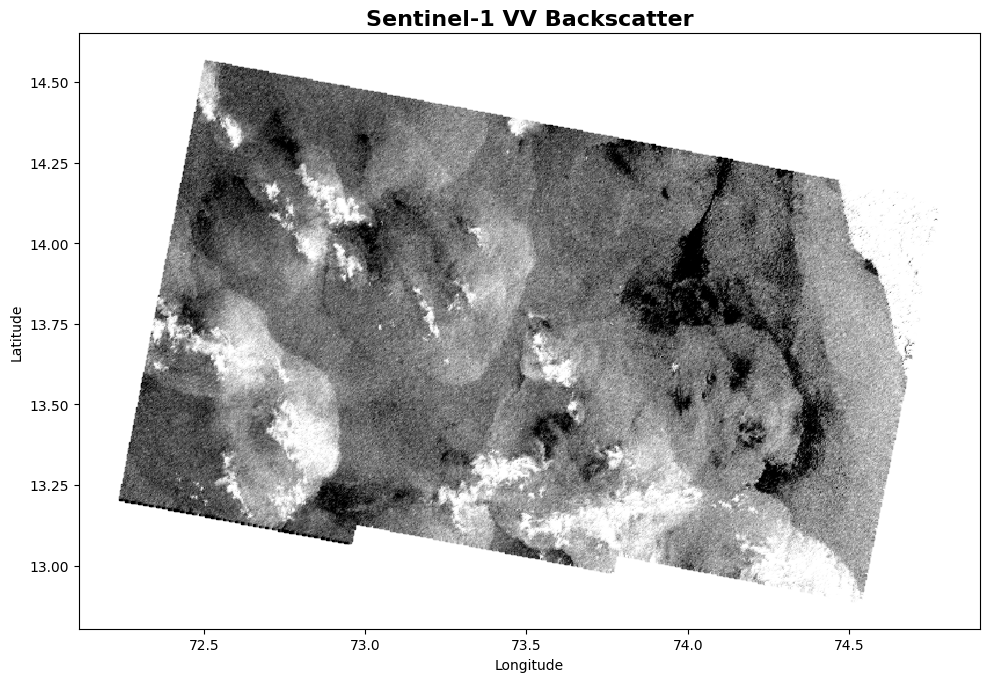

In [ ]:
# ==========================================================
# Display Downsampled Image and Describe dataset
# ==========================================================

PARQUET_FILE = "collocated_2.parquet"
df = pd.read_parquet(PARQUET_FILE)
print(df.describe())

# Increase to brighten image
BRIGHTNESS = 1.2

# Contrast stretch percentiles
LOW_PERCENTILE = 3
HIGH_PERCENTILE = 98

# Marker size
POINT_SIZE = 1

#Polarization channel
vv = df["VV_dB"].values

#Stretch
p_low = np.percentile(vv, LOW_PERCENTILE)
p_high = np.percentile(vv, HIGH_PERCENTILE)
vv_scaled = (vv - p_low) / (p_high - p_low)
vv_scaled = np.clip(vv_scaled, 0, 1)

# brightness control
vv_scaled = vv_scaled * BRIGHTNESS
vv_scaled = np.clip(vv_scaled, 0, 1)

fig, ax = plt.subplots(
    figsize=(10,10)
)

scatter = ax.scatter(
    df["lon"],
    df["lat"],
    c=vv_scaled,
    cmap="gray",
    s=POINT_SIZE,
    marker="s"
)

ax.set_title(
    "Sentinel-1 VV Backscatter",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.set_aspect("equal")

plt.tight_layout()

plt.show()

### Remove land points

Use a land polygon shapefile to remove collocated samples that fall on land, keeping the analysis focused on ocean-surface radar returns. This is important because the project objective is to study rainfall impacts on SAR backscatter, and ocean scenes are generally more relevant for that comparison than mixed land pixels.

In [ ]:
# =======================================
# REMOVE LAND Data from parquet 
# =======================================

# Files
PARQUET_FILE = r"collocated_2.parquet"
LAND_SHP = r"ne_10m_land.shp"

LAT_COL = "lat"
LON_COL = "lon"

df = pd.read_parquet(PARQUET_FILE)
original_count = len(df)
print(f"Original points: {original_count:,}")

points = gpd.GeoSeries(
    [Point(lon, lat) for lon, lat in zip(df[LON_COL], df[LAT_COL])],
    crs="EPSG:4326"
)
land = gpd.read_file(LAND_SHP)
land_union = land.union_all()
is_land = points.within(land_union)

df_ocean = df[~is_land].copy()
ocean_count = len(df_ocean)
print(f"Ocean points: {ocean_count:,}")
print(f"Removed land: {original_count - ocean_count:,}")

df_ocean.to_parquet(
    PARQUET_FILE,
    index=False
)

print("Done.")
print(f"Updated file: {PARQUET_FILE}")


Original points: 238,408
Ocean points: 231,641
Removed land: 6,767
Done.
Updated file: collocated_2.parquet


### Build the SAR-rain overlay

Create an interactive overlay that places IMERG rainfall on top of the SAR image so spatial coincidence can be checked by eye. The sliders make it easy to change transparency and rainfall thresholds while visually exploring how rain patches align with radar backscatter patterns.

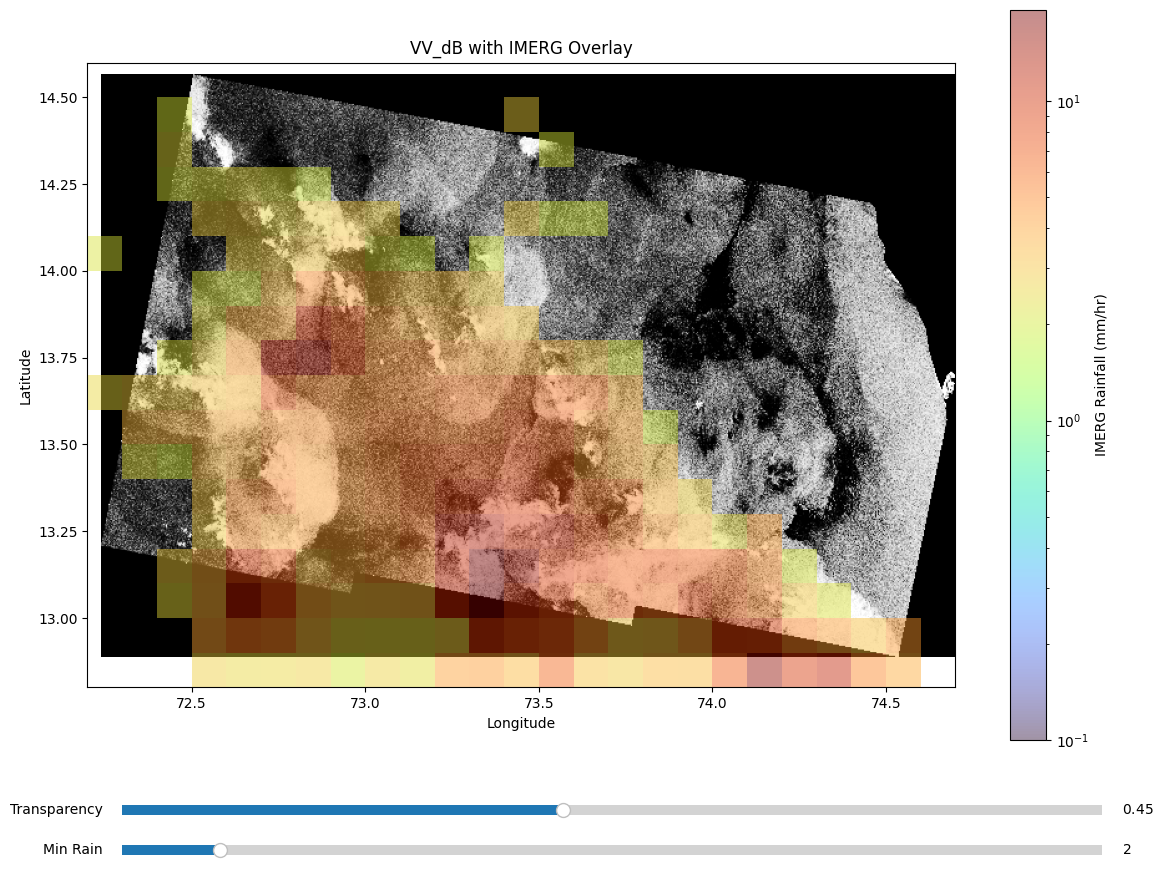

In [ ]:
# =====================================================
# CREATE OVERLAY IMAGE
# =====================================================

PARQUET = "collocated_2.parquet"
IMERG_FILE = "IMERG_2.HDF5"
RAIN_THRESHOLD = 2
SAR_BAND = "VV_dB"

# Load SAR from parquet
df = pd.read_parquet(PARQUET)

lat_min = df["lat"].min()
lat_max = df["lat"].max()

lon_min = df["lon"].min()
lon_max = df["lon"].max()

lats = np.sort(df["lat"].unique())
lons = np.sort(df["lon"].unique())

lat_idx = {v:i for i,v in enumerate(lats)}
lon_idx = {v:i for i,v in enumerate(lons)}

sar = np.full(
    (len(lats), len(lons)),
    np.nan,
    dtype=np.float32
)

for row in df.itertuples():
    sar[
        lat_idx[row.lat],
        lon_idx[row.lon]
    ] = getattr(row, SAR_BAND)

p2 = np.nanpercentile(sar,2)
p98 = np.nanpercentile(sar,98)

sar = np.clip(
    (sar-p2)/(p98-p2),
    0,
    1
)

sar = exposure.equalize_hist(
    np.nan_to_num(sar)
)

# LOAD IMERG
with h5py.File(IMERG_FILE,"r") as f:

    if "Grid/precipitation" in f:
        rain = f["Grid/precipitation"][:]

    else:
        rain = f["Grid/precipitationCal"][:]

    imerg_lat = f["Grid/lat"][:]
    imerg_lon = f["Grid/lon"][:]

rain = np.squeeze(rain)

if rain.shape[0] == len(imerg_lon):
    rain = rain.T

margin = 0.05

lat_mask = (
    (imerg_lat >= lat_min-margin)
    &
    (imerg_lat <= lat_max+margin)
)

lon_mask = (
    (imerg_lon >= lon_min-margin)
    &
    (imerg_lon <= lon_max+margin)
)

rain = rain[
    lat_mask,
    :
][:,
    lon_mask
]

imerg_lat = imerg_lat[lat_mask]
imerg_lon = imerg_lon[lon_mask]

# Edges
dlat = np.mean(np.diff(imerg_lat))
dlon = np.mean(np.diff(imerg_lon))

lat_edges = np.concatenate(
[
    [imerg_lat[0]-dlat/2],
    imerg_lat[:-1]+dlat/2,
    [imerg_lat[-1]+dlat/2]
])

lon_edges = np.concatenate(
[
    [imerg_lon[0]-dlon/2],
    imerg_lon[:-1]+dlon/2,
    [imerg_lon[-1]+dlon/2]
])

# FIGURE
fig, ax = plt.subplots(
    figsize=(14,10)
)

plt.subplots_adjust(
    bottom=0.15
)

ax.imshow(
    sar,
    cmap="gray",
    origin="lower",
    extent=[
        lon_min,
        lon_max,
        lat_min,
        lat_max
    ]
)

rain_display = rain.copy()

rain_display[
    rain_display < RAIN_THRESHOLD
] = np.nan

mesh = ax.pcolormesh(
    lon_edges,
    lat_edges,
    rain_display,

    cmap="turbo",

    norm=LogNorm(
        vmin=0.1,
        vmax=max(
            10,
            np.nanmax(rain)
        )
    ),

    alpha=0.45,

    shading="flat"
)

# COLORBAR
cbar = plt.colorbar(
    mesh,
    ax=ax
)

cbar.set_label(
    "IMERG Rainfall (mm/hr)"
)

# SLIDERS
alpha_ax = plt.axes(
    [0.15,0.07,0.7,0.02]
)

thr_ax = plt.axes(
    [0.15,0.03,0.7,0.02]
)

alpha_slider = Slider(
    alpha_ax,
    "Transparency",
    0,
    1,
    valinit=0.45
)

thr_slider = Slider(
    thr_ax,
    "Min Rain",
    0,
    20,
    valinit=RAIN_THRESHOLD
)

# UPDATE
def update(val):

    mesh.set_alpha(
        alpha_slider.val
    )

    rain_new = rain.copy()

    rain_new[
        rain_new < thr_slider.val
    ] = np.nan

    mesh.set_array(
        rain_new.ravel()
    )

    fig.canvas.draw_idle()

alpha_slider.on_changed(update)
thr_slider.on_changed(update)

# LABELS
ax.set_title(
    f"{SAR_BAND} with IMERG Overlay"
)
ax.set_xlabel(
    "Longitude"
)
ax.set_ylabel(
    "Latitude"
)
plt.show()

### Analyze incidence-angle trends

Group the collocated samples into 1-degree incidence-angle bins and summarize VV, VH, VH-VV, and rainfall in each bin. Incidence angle matters because SAR backscatter changes with viewing geometry, so this plot helps separate geometric effects from rainfall-related variability.

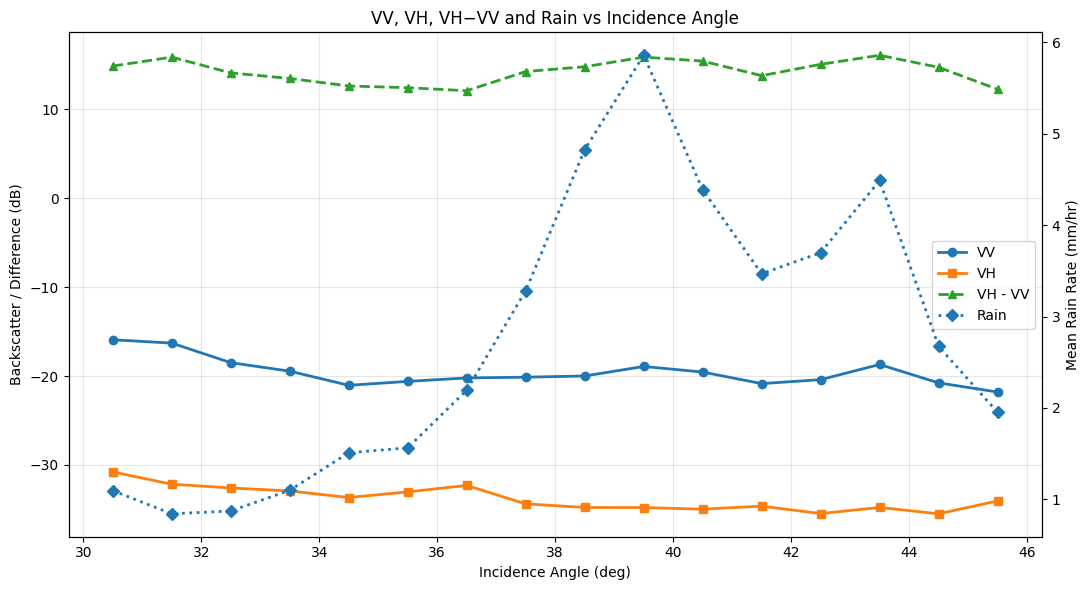

                       VV         VH  VV_minus_VH   Rain  Count
angle_bin                                                      
(28.999, 30.0]        NaN        NaN          NaN    NaN      0
(30.0, 31.0]   -15.920000 -30.787001       14.867  1.096   1286
(31.0, 32.0]   -16.296000 -32.166000       15.871  0.843   9098
(32.0, 33.0]   -18.497000 -32.590000       14.092  0.874  11173
(33.0, 34.0]   -19.452000 -32.924000       13.472  1.100  13306
(34.0, 35.0]   -21.042000 -33.666000       12.624  1.511  13745
(35.0, 36.0]   -20.603001 -33.032001       12.429  1.564  14008
(36.0, 37.0]   -20.216000 -32.306999       12.091  2.195  14691
(37.0, 38.0]   -20.129999 -34.377998       14.247  3.283  15291
(38.0, 39.0]   -19.995001 -34.784000       14.789  4.825  15606
(39.0, 40.0]   -18.924999 -34.796001       15.871  5.859  15967
(40.0, 41.0]   -19.551001 -34.974998       15.423  4.388  16323
(41.0, 42.0]   -20.851999 -34.634998       13.783  3.468  16929
(42.0, 43.0]   -20.406000 -35.469002    

In [ ]:
# ==========================
# PLOT#1 Data vs Incidence Angle
# ==========================

COLLOCATED_DATAFILE="collocated_2.parquet"

df = pd.read_parquet(COLLOCATED_DATAFILE)

bins = np.arange(29, 47, 1)
df["angle_bin"] = pd.cut(df["incidence_angle"],bins=bins,include_lowest=True)

stats = (
    df.groupby("angle_bin", observed=False)
      .agg(
          VV=("VV_dB", "mean"),
          VH=("VH_dB", "mean"),
          Rain=("rain_mm_hr", "mean"),
          Count=("VV_dB", "size")
      )
)

# VH - VV difference (dB)
stats["VV_minus_VH"] = stats["VV"] - stats["VH"]

# Bin centers
x = [b.mid for b in stats.index]

# Plot
fig, ax1 = plt.subplots(figsize=(11, 6))

# Left axis: SAR variables
l1 = ax1.plot(
    x, stats["VV"],
    marker="o",
    linewidth=2,
    label="VV"
)

l2 = ax1.plot(
    x, stats["VH"],
    marker="s",
    linewidth=2,
    label="VH"
)

l3 = ax1.plot(
    x, stats["VV_minus_VH"],
    marker="^",
    linestyle="--",
    linewidth=2,
    label="VH - VV"
)

ax1.set_xlabel("Incidence Angle (deg)")
ax1.set_ylabel("Backscatter / Difference (dB)")
ax1.grid(True, alpha=0.3)

# Right axis: Rain
ax2 = ax1.twinx()

l4 = ax2.plot(
    x, stats["Rain"],
    marker="D",
    linewidth=2,
    linestyle=":",
    label="Rain"
)

ax2.set_ylabel("Mean Rain Rate (mm/hr)")

# Combined legend
lines = l1 + l2 + l3 + l4
labels = [line.get_label() for line in lines]

ax1.legend(lines, labels, loc="best")

plt.title("VV, VH, VH−VV and Rain vs Incidence Angle")

plt.tight_layout()
plt.show()

# Print statistics
print(
    stats[
        ["VV", "VH", "VV_minus_VH", "Rain", "Count"]
    ].round(3)
)

### Correct incidence-angle dependence

Fit a linear model against incidence angle for VV and VH, then subtract the predicted trend from the measured values. This detrending step reduces geometry-driven bias so the remaining signal is better suited for studying rainfall-related backscatter behavior.

In [ ]:
# ========================================================
# REMOVE Incidence Angle effect through linear regression
# ========================================================

input_file = "collocated_2.parquet"
output_file = "collocated_2_icorrected.parquet"

# LOAD DATA
df = pd.read_parquet(input_file)
X = df[["incidence_angle"]]

vv_model = LinearRegression()
vv_model.fit(X, df["VV_dB"])
vv_expected = vv_model.predict(X)
df["VV_dB"] = df["VV_dB"] - vv_expected

vh_model = LinearRegression()
vh_model.fit(X, df["VH_dB"])
vh_expected = vh_model.predict(X)
df["VH_dB"] = df["VH_dB"] - vh_expected

print("\nVV slope:")
print(vv_model.coef_[0])
print("\nVH slope:")
print(vh_model.coef_[0])

# SAVE
df.to_parquet(output_file, index=False)
print(f"\nSaved angle-corrected dataset to: {output_file}")


VV slope:
-0.13964935

VH slope:
-0.19767259

Saved angle-corrected dataset to: collocated_2_icorrected.parquet


### Replot after angle correction

Repeat the incidence-angle bin analysis using the angle-corrected dataset to check whether the systematic slope has been reduced. If the correction worked, VV and VH should vary less with incidence angle and the rain comparison becomes easier to interpret.

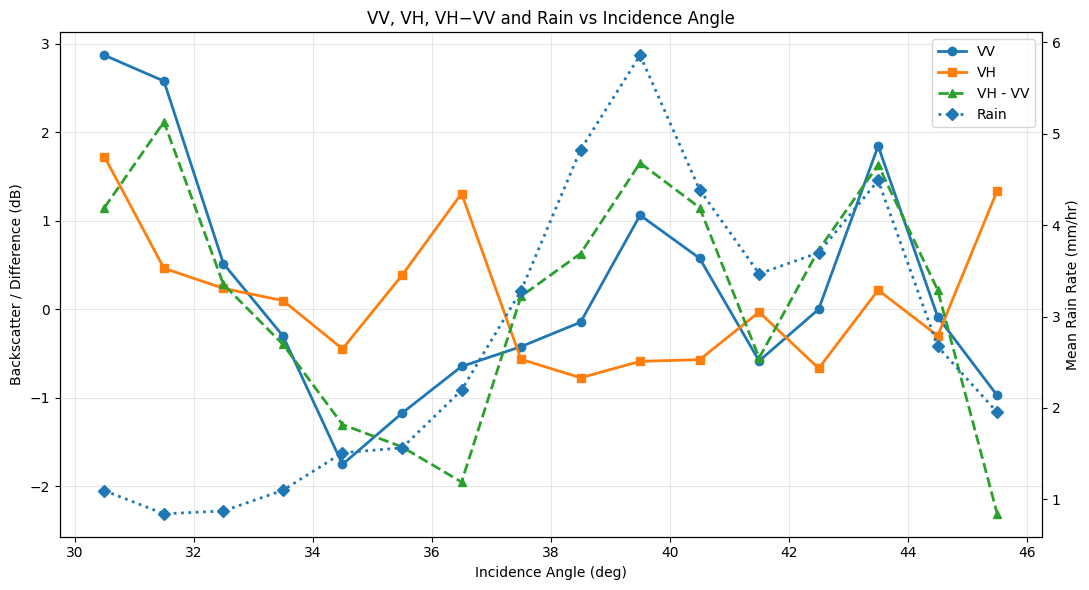

                   VV     VH  VV_minus_VH   Rain  Count
angle_bin                                              
(28.999, 30.0]    NaN    NaN          NaN    NaN      0
(30.0, 31.0]    2.868  1.722        1.146  1.096   1286
(31.0, 32.0]    2.576  0.461        2.115  0.843   9098
(32.0, 33.0]    0.512  0.234        0.278  0.874  11173
(33.0, 34.0]   -0.304  0.096       -0.400  1.100  13306
(34.0, 35.0]   -1.755 -0.450       -1.305  1.511  13745
(35.0, 36.0]   -1.176  0.382       -1.558  1.564  14008
(36.0, 37.0]   -0.649  1.306       -1.955  2.195  14691
(37.0, 38.0]   -0.424 -0.568        0.144  3.283  15291
(38.0, 39.0]   -0.149 -0.776        0.628  4.825  15606
(39.0, 40.0]    1.060 -0.591        1.651  5.859  15967
(40.0, 41.0]    0.574 -0.572        1.146  4.388  16323
(41.0, 42.0]   -0.586 -0.034       -0.552  3.468  16929
(42.0, 43.0]   -0.002 -0.671        0.669  3.700  17967
(43.0, 44.0]    1.842  0.214        1.628  4.489  18425
(44.0, 45.0]   -0.088 -0.302        0.214  2.673

In [ ]:
# ==========================================================
# PLOT#2 Data vs Incidence Angle after removing its effect
# ==========================================================

COLLOCATED_DATAFILE="collocated_2_icorrected.parquet"

df = pd.read_parquet(COLLOCATED_DATAFILE)

bins = np.arange(29, 47, 1)
df["angle_bin"] = pd.cut(df["incidence_angle"],bins=bins,include_lowest=True)

stats = (
    df.groupby("angle_bin", observed=False)
      .agg(
          VV=("VV_dB", "mean"),
          VH=("VH_dB", "mean"),
          Rain=("rain_mm_hr", "mean"),
          Count=("VV_dB", "size")
      )
)

# VH - VV difference (dB)
stats["VV_minus_VH"] = stats["VV"] - stats["VH"]

# Bin centers
x = [b.mid for b in stats.index]

# Plot
fig, ax1 = plt.subplots(figsize=(11, 6))

# Left axis: SAR variables
l1 = ax1.plot(
    x, stats["VV"],
    marker="o",
    linewidth=2,
    label="VV"
)

l2 = ax1.plot(
    x, stats["VH"],
    marker="s",
    linewidth=2,
    label="VH"
)

l3 = ax1.plot(
    x, stats["VV_minus_VH"],
    marker="^",
    linestyle="--",
    linewidth=2,
    label="VH - VV"
)

ax1.set_xlabel("Incidence Angle (deg)")
ax1.set_ylabel("Backscatter / Difference (dB)")
ax1.grid(True, alpha=0.3)

# Right axis: Rain
ax2 = ax1.twinx()

l4 = ax2.plot(
    x, stats["Rain"],
    marker="D",
    linewidth=2,
    linestyle=":",
    label="Rain"
)

ax2.set_ylabel("Mean Rain Rate (mm/hr)")

# Combined legend
lines = l1 + l2 + l3 + l4
labels = [line.get_label() for line in lines]

ax1.legend(lines, labels, loc="best")

plt.title("VV, VH, VH−VV and Rain vs Incidence Angle")

plt.tight_layout()
plt.show()

# Print statistics
print(
    stats[
        ["VV", "VH", "VV_minus_VH", "Rain", "Count"]
    ].round(3)
)

### Compare rainfall and backscatter

Bin the collocated observations by rainfall amount and compute mean VV and VH for each rain interval. This diagnostic summarizes how the radar response changes across light to heavy rainfall conditions and is useful for checking whether backscatter systematically tracks rain intensity.

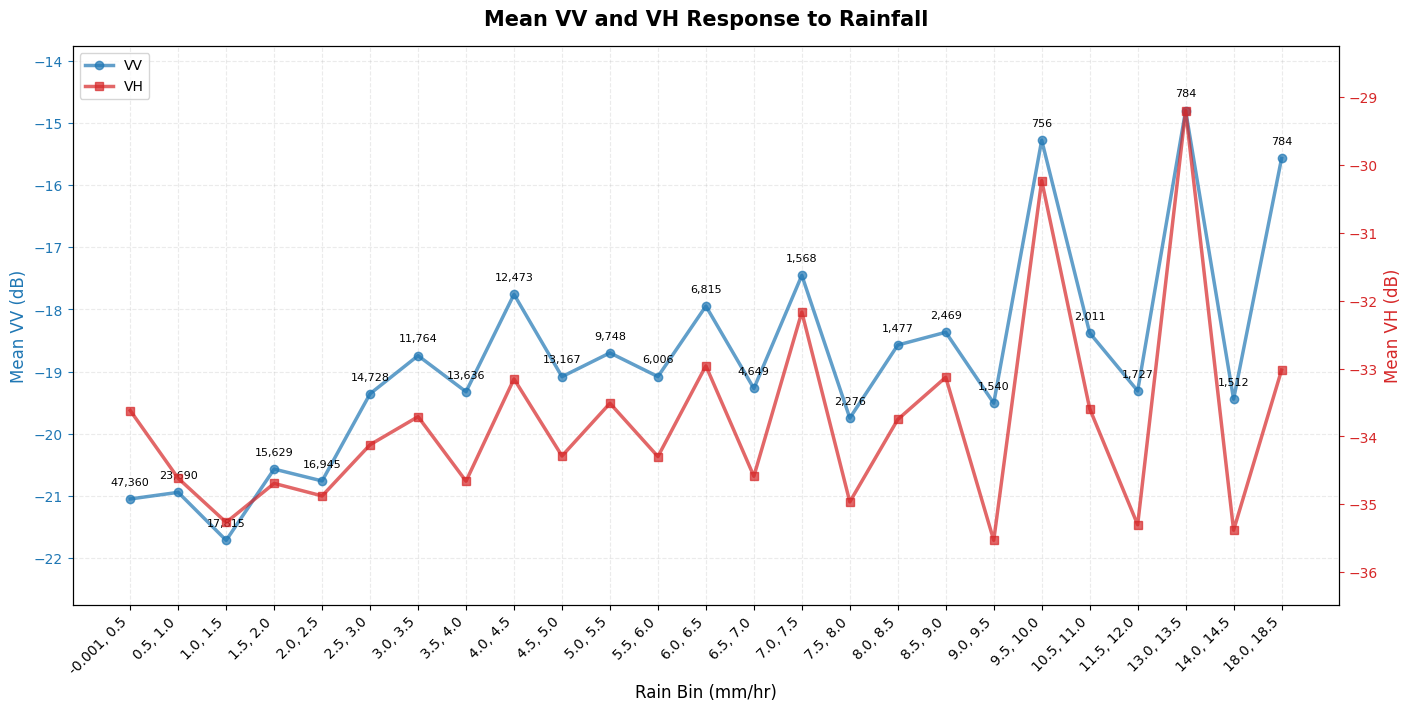


Rain Bin Statistics

     rain_bin    VV_mean    VH_mean  count
(-0.001, 0.5] -21.052000 -33.618999  47360
   (0.5, 1.0] -20.945000 -34.617001  23690
   (1.0, 1.5] -21.718000 -35.265999  17815
   (1.5, 2.0] -20.570999 -34.692001  15629
   (2.0, 2.5] -20.761999 -34.876999  16945
   (2.5, 3.0] -19.358000 -34.122002  14728
   (3.0, 3.5] -18.745001 -33.709000  11764
   (3.5, 4.0] -19.326000 -34.660000  13636
   (4.0, 4.5] -17.757999 -33.153000  12473
   (4.5, 5.0] -19.083000 -34.287998  13167
   (5.0, 5.5] -18.700001 -33.512001   9748
   (5.5, 6.0] -19.082001 -34.297001   6006
   (6.0, 6.5] -17.947001 -32.960999   6815
   (6.5, 7.0] -19.273001 -34.587002   4649
   (7.0, 7.5] -17.452000 -32.167999   1568
   (7.5, 8.0] -19.749001 -34.965000   2276
   (8.0, 8.5] -18.573999 -33.750000   1477
   (8.5, 9.0] -18.368000 -33.129002   2469
   (9.0, 9.5] -19.510000 -35.530998   1540
  (9.5, 10.0] -15.277000 -30.231001    756
 (10.5, 11.0] -18.379000 -33.591000   2011
 (11.5, 12.0] -19.312000 -35.300

In [ ]:
# ==========================================================
# PLOT #3 DATA vs RAIN analysis
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# CONFIG
# ==========================================================

FILE = "collocated_2.parquet"

RAIN_COL = "rain_mm_hr"
VV_COL   = "VV_dB"
VH_COL   = "VH_dB"

MIN_COUNT = 500

# ==========================================================
# LOAD DATA
# ==========================================================

df = pd.read_parquet(FILE)

df = df.dropna(
    subset=[
        RAIN_COL,
        VV_COL,
        VH_COL
    ]
)

BINS = np.arange(
    df["rain_mm_hr"].min(),
    df["rain_mm_hr"].max()+0.5,
    0.5
)

# ==========================================================
# CREATE RAIN BINS
# ==========================================================

df["rain_bin"] = pd.cut(
    df[RAIN_COL],
    bins=BINS,
    include_lowest=True
)

# ==========================================================
# COMPUTE BIN STATS
# ==========================================================

stats = (
    df
    .groupby("rain_bin", observed=True)
    .agg(
        VV_mean=(VV_COL, "mean"),
        VH_mean=(VH_COL, "mean"),
        count=(RAIN_COL, "size")
    )
    .reset_index()
)

stats = stats[
    stats["count"] >= MIN_COUNT
].copy()

# ==========================================================
# LABELS
# ==========================================================

labels = [
    str(x)
    .replace("(", "")
    .replace("]", "")
    for x in stats["rain_bin"]
]

x = np.arange(len(stats))

# PLOT
fig, ax = plt.subplots(
    figsize=(14,7),
    constrained_layout=True
)

ax2 = ax.twinx()

# VV
vv_line = ax.plot(
    x,
    stats["VV_mean"],
    marker='o',
    markersize=6,
    linewidth=2.5,
    color='tab:blue',
    label='VV',
    alpha=0.7
)[0]

# VH
vh_line = ax2.plot(
    x,
    stats["VH_mean"],
    marker='s',
    markersize=6,
    linewidth=2.5,
    color='tab:red',
    label='VH',
    alpha=0.7

)[0]

for xi, yi, count in zip(
        x,
        stats["VV_mean"],
        stats["count"]
):

    ax.annotate(
        f'{count:,}',
        (xi, yi),
        xytext=(0, 10),
        textcoords='offset points',
        ha='center',
        fontsize=8,
        color='black'
    )

ax.set_xticks(x)

ax.set_xticklabels(
    labels,
    rotation=45,
    ha='right'
)

ax.set_xlabel(
    'Rain Bin (mm/hr)',
    fontsize=12
)

ax.set_ylabel(
    'Mean VV (dB)',
    fontsize=12,
    color='tab:blue'
)

ax2.set_ylabel(
    'Mean VH (dB)',
    fontsize=12,
    color='tab:red'
)

ax.tick_params(
    axis='y',
    colors='tab:blue'
)

ax2.tick_params(
    axis='y',
    colors='tab:red'
)

# GRID
ax.grid(
    True,
    linestyle='--',
    linewidth=0.8,
    alpha=0.25
)

handles = [
    vv_line,
    vh_line
]

labels_leg = [
    h.get_label()
    for h in handles
]

ax.legend(
    handles,
    labels_leg,
    loc='upper left',
    frameon=True,
    fontsize=10
)

ax.set_title(
    'Mean VV and VH Response to Rainfall',
    fontsize=15,
    fontweight='bold',
    pad=15
)

vvmin = stats["VV_mean"].min()
vvmax = stats["VV_mean"].max()

pad = max(0.15,(vvmax-vvmin)*0.15)

ax.set_ylim(vvmin-pad,vvmax+pad)

vhmin = stats["VH_mean"].min()
vhmax = stats["VH_mean"].max()

pad = max(
    0.15,
    (vhmax-vhmin)*0.15
)

ax2.set_ylim(vhmin-pad,vhmax+pad)

plt.show()
print("\nRain Bin Statistics\n")
print(stats.round(3).to_string(index=False))


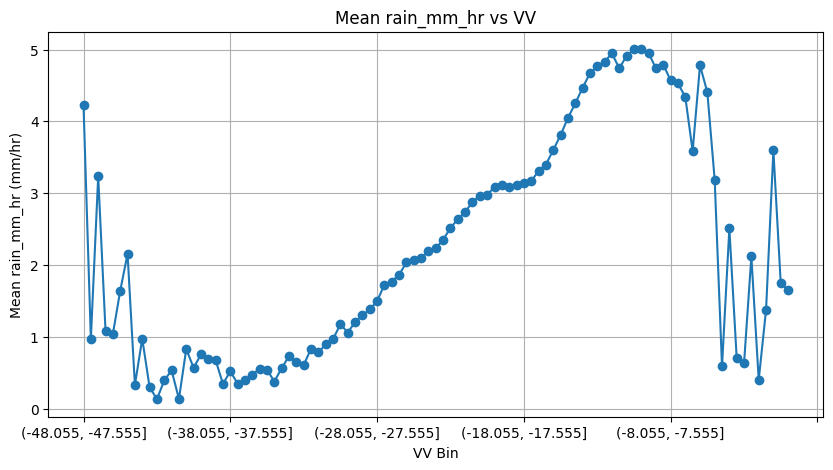

In [ ]:
# ==========================================================
# PLOT #4 RAIN vs DATA analysis
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_parquet("collocated_2.parquet")

bins = np.arange(
    df["VV_dB"].min(),
    df["VV_dB"].max()+0.5,
    0.5
)

df["VV_bin"] = pd.cut(df["VV_dB"], bins)

rain_mean = df.groupby("VV_bin",observed=False)["rain_mm_hr"].mean()

plt.figure(figsize=(10,5))

rain_mean.plot(marker='o')

plt.ylabel("Mean rain_mm_hr (mm/hr)")
plt.xlabel("VV Bin")
plt.title("Mean rain_mm_hr vs VV")

plt.grid(True)
plt.show()


### Compute Spearman correlations

Calculate Spearman rank correlations between rainfall, VV, VH, and VH-VV to measure monotonic relationships without assuming a linear model. This is a compact way to quantify whether higher rain rates tend to align with consistent changes in SAR backscatter.


spearman Correlation Matrix

             rain_mm_hr   VV_dB   VH_dB  VV_minus_VH
rain_mm_hr       1.0000  0.3087  0.0827       0.1943
VV_dB            0.3087  1.0000  0.3026       0.5216
VH_dB            0.0827  0.3026  1.0000      -0.5919
VV_minus_VH      0.1943  0.5216 -0.5919       1.0000


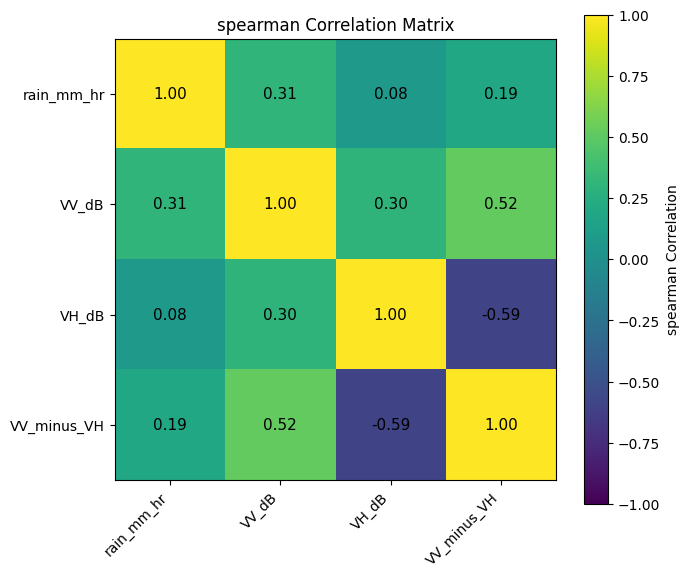

In [ ]:
# =====================================================
# PLOT #5 Spearman Correlation Matrix
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt

FILE = "collocated_2_icorrected.parquet"

RAIN = "rain_mm_hr"
VV   = "VV_dB"
VH   = "VH_dB"

df = pd.read_parquet(FILE)

df["VV_minus_VH"] = df[VV] - df[VH]

vars_to_use = [
    RAIN,
    VV,
    VH,
    "VV_minus_VH"
]

corr = df[vars_to_use].corr(method="spearman")

print("\nspearman Correlation Matrix\n")
print(corr.round(4))

fig, ax = plt.subplots(figsize=(7,6))

im = ax.imshow(
    corr,
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))

ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)

for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(
            j,
            i,
            f"{corr.iloc[i,j]:.2f}",
            ha="center",
            va="center",
            fontsize=11
        )

plt.colorbar(im, label="spearman Correlation")

plt.title("spearman Correlation Matrix")
plt.tight_layout()
plt.show()

### Interactive binary overlays

Turn rainfall and SAR values into binary masks using adjustable thresholds and display them as stacked images. The sliders let you explore how different rain and backscatter cutoffs change the agreement between the two layers, which is useful for rapid threshold tuning and visual classification.

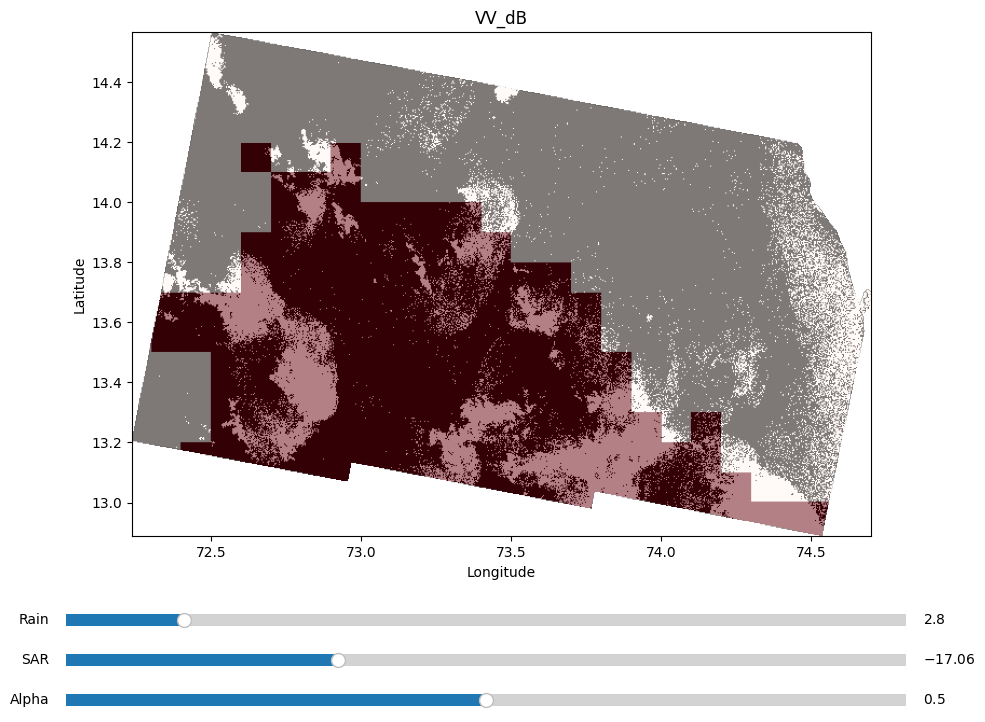

In [ ]:
# ===============================================================
# PLOT #6 Binary Maps Overlayed with auto best threshold finder
# ===============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

#Parameters
FILE = "collocated_2.parquet"
SAR_VARIABLE = "VV_dB"

INITIAL_RAIN_THRESHOLD = 2.8
INITIAL_SAR_THRESHOLD = -16.1
INITIAL_ALPHA = 0.5

# Read
df = pd.read_parquet(FILE)
if SAR_VARIABLE == "VV_minus_VH":
    sar_values = df["VV_dB"] - df["VH_dB"]

elif SAR_VARIABLE == "VV_minus_VH":
    sar_values = df["VV_dB"] - df["VH_dB"]

else:
    sar_values = df[SAR_VARIABLE]

# Find Best SAR threshold for given rain threshold and set it as intial
thresholds = np.arange(df[SAR_VARIABLE].min(),df[SAR_VARIABLE].max()+0.5,0.5)
best_accuracy=0
for t in thresholds:
    rain_pred = df["VV_dB"] > t
    rain_true = df["rain_mm_hr"] > INITIAL_RAIN_THRESHOLD
    accuracy = (rain_pred == rain_true).mean()
    if accuracy>=best_accuracy:
        best_accuracy=accuracy
        INITIAL_SAR_THRESHOLD=t

# GRID SETUP
lons = np.sort(df.lon.unique())
lats = np.sort(df.lat.unique())

nx = len(lons)
ny = len(lats)

lon_idx = {v:i for i,v in enumerate(lons)}
lat_idx = {v:i for i,v in enumerate(lats)}

extent = (
    float(lons.min()),
    float(lons.max()),
    float(lats.min()),
    float(lats.max())
)

# BUILD MASK FUNCTION
def build_masks(rain_thr, sar_thr):

    rain_img = np.full((ny,nx), np.nan)
    sar_img = np.full((ny,nx), np.nan)

    rain_mask = (
            df["rain_mm_hr"] >= rain_thr
    ).astype(np.uint8)

    sar_mask = (
            sar_values >= sar_thr
    ).astype(np.uint8)
    
    for lon,lat,rain,sar in zip(df.lon,df.lat,rain_mask,sar_mask):
        
        x = lon_idx[lon]
        y = lat_idx[lat]
        rain_img[y,x] = rain
        sar_img[y,x] = sar
        
    return rain_img,sar_img

# INITIAL MASKS
rain_img,sar_img = build_masks(
        INITIAL_RAIN_THRESHOLD,
        INITIAL_SAR_THRESHOLD
)

# Figure
fig,ax = plt.subplots(figsize=(12,8))
plt.subplots_adjust(bottom=0.25)
im1 = ax.imshow(
        sar_img,
        extent=extent,
        origin='lower',
        cmap='gray',
        vmin=0,
        vmax=1
)

im2 = ax.imshow(
        rain_img,
        extent=extent,
        origin='lower',
        cmap='Reds',
        alpha=INITIAL_ALPHA,
        vmin=0,
        vmax=1
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

title = ax.set_title(f"{SAR_VARIABLE}")

# Sliders
ax_rain = plt.axes((0.15,0.13,0.70,0.03))
ax_sar = plt.axes((0.15,0.08,0.70,0.03))
ax_alpha = plt.axes((0.15,0.03,0.70,0.03))

slider_rain = Slider(
        ax_rain,
        'Rain',
        0,
        20,
        valinit=INITIAL_RAIN_THRESHOLD
)

slider_sar = Slider(
        ax_sar,
        'SAR',
        -30,
        10,
        valinit=INITIAL_SAR_THRESHOLD
)

slider_alpha = Slider(
        ax_alpha,
        'Alpha',
        0,
        1,
        valinit=INITIAL_ALPHA
)

def update(_):
    rain_thr = slider_rain.val
    sar_thr = slider_sar.val
    alpha = slider_alpha.val
    rain_img,sar_img = build_masks(rain_thr,sar_thr)
    im1.set_data(sar_img)
    im2.set_data(rain_img)
    im2.set_alpha(alpha)
    title.set_text(f"{SAR_VARIABLE} ≥ {sar_thr:.2f}     Rain ≥ {rain_thr:.2f}")
    fig.canvas.draw_idle()
    
slider_rain.on_changed(update)
slider_sar.on_changed(update)
slider_alpha.on_changed(update)

plt.show()